In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8')

print("Imports done!")

Imports done!


In [2]:
df = pd.read_csv('data/raw/telco_churn.csv')
print("Dataset loaded!")
print(f"Shape: {df.shape}")

Dataset loaded!
Shape: (7043, 21)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [5]:
print(f"Rows     : {df.shape[0]}")
print(f"Columns  : {df.shape[1]}")
print(f"\nDataset Info:")
df.info()

Rows     : 7043
Columns  : 21

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  Paperles

In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Show only columns that have missing values
print("Columns with missing values:")
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Columns with missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


Churn Distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%
Retention Rate: 73.5%


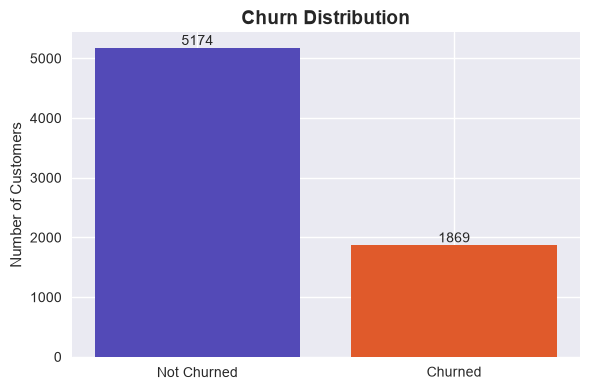

Chart saved to reports folder!


In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_counts)
print(f"\nChurn Rate: {churn_pct['Yes']:.1f}%")
print(f"Retention Rate: {churn_pct['No']:.1f}%")

# Plot it
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(['Not Churned', 'Churned'],
              churn_counts.values,
              color=['#534AB7', '#E05A2B'])
ax.bar_label(bars, fmt='%d')
ax.set_title('Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('reports/churn_distribution.png', dpi=150)
plt.show()
print("Chart saved to reports folder!")

In [8]:
print("Numerical columns summary:")
df.describe()

Numerical columns summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [9]:
# TotalCharges is stored as text (object) instead of number — a known issue in this dataset
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("\nSample values:", df['TotalCharges'].head(10).tolist())

# Fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("\nAfter fix, dtype:", df['TotalCharges'].dtype)
print("New nulls created:", df['TotalCharges'].isnull().sum())

TotalCharges dtype: str

Sample values: ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']

After fix, dtype: float64
New nulls created: 11


In [20]:
notes = """
## Day 2 EDA Notes

**Dataset:** IBM Telco Customer Churn
**Shape:** 7043 rows × 21 columns

**Key findings:**
- Churn rate is ~26.5% — class imbalance exists, will need SMOTE later
- TotalCharges column is object type, needs conversion to float
- 11 rows have blank TotalCharges (all have tenure=0, new customers)
- No other missing values in the dataset

**Next steps (Day 3):**
- Univariate analysis: distribution plots for all features
- Bivariate analysis: each feature vs Churn
- Correlation heatmap
"""

with open('reports/eda_notes.md', 'w') as f:
    f.write(notes)

print("Notes saved!")

Notes saved!


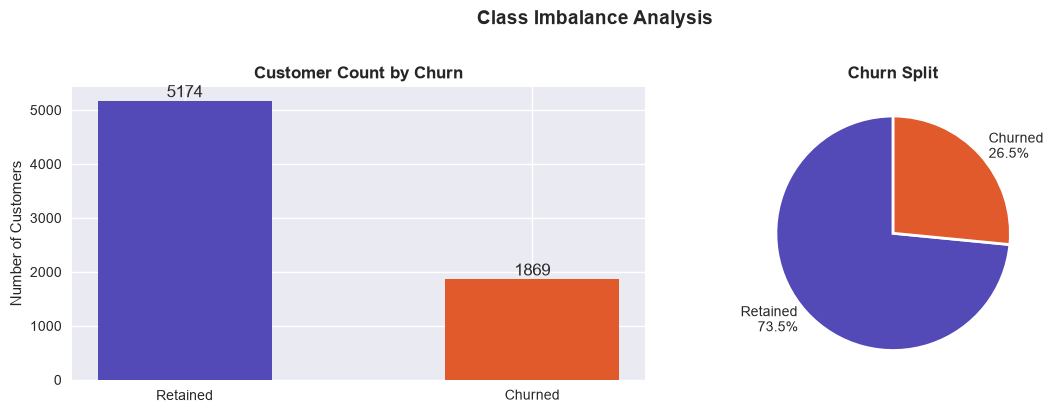

Retained : 5174  (73.5%)
Churned  : 1869 (26.5%)

Class imbalance ratio: 2.77:1 


In [ ]:
#  class imbalance visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 — bar chart
churn_counts = df['Churn'].value_counts()
bars = axes[0].bar(['Retained', 'Churned'],
                    churn_counts.values,
                    color=['#534AB7', '#E05A2B'], width=0.5)
axes[0].bar_label(bars, fmt='%d', fontsize=12)
axes[0].set_title('Customer Count by Churn', fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# Plot 2 — pie chart
axes[1].pie(churn_counts.values,
            labels=[f"Retained\n{churn_pct['No']:.1f}%",f"Churned\n{churn_pct['Yes']:.1f}%"],
            colors=['#534AB7', '#E05A2B'],
            startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Churn Split', fontweight='bold')

plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Retained : {churn_counts['No']}  ({churn_counts['No']/len(df)*100:.1f}%)")
print(f"Churned  : {churn_counts['Yes']} ({churn_counts['Yes']/len(df)*100:.1f}%)")
ratio = churn_counts.max()/churn_counts.min()
print(f"\nClass imbalance ratio: {ratio:.2f}:1 ")

In [ ]:
#  identify numerical vs categorical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

print(f"Numerical columns  ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Target column: Churn")

Numerical columns  (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target column: Churn


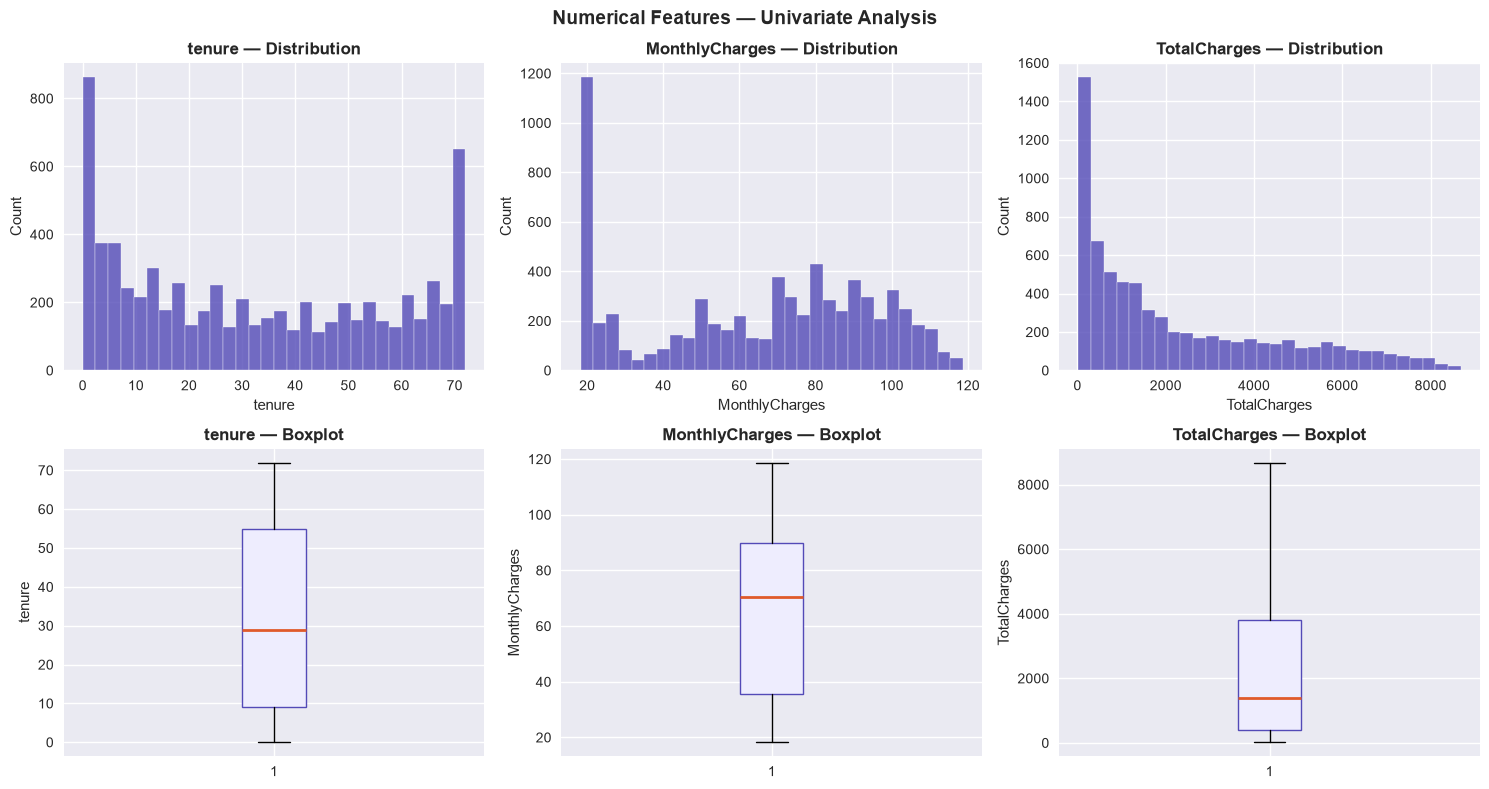

In [ ]:
#  distribution of numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(numerical_cols):
    # Top row — histogram
    axes[0][idx].hist(df[col].dropna(), bins=30,
                      color='#534AB7', edgecolor='white', alpha=0.8)
    axes[0][idx].set_title(f'{col} — Distribution', fontweight='bold')
    axes[0][idx].set_xlabel(col)
    axes[0][idx].set_ylabel('Count')

    # Bottom row — boxplot
    axes[1][idx].boxplot(df[col].dropna(), patch_artist=True,
                          boxprops=dict(facecolor='#EEEDFE', color='#534AB7'),
                          medianprops=dict(color='#E05A2B', linewidth=2))
    axes[1][idx].set_title(f'{col} — Boxplot', fontweight='bold')
    axes[1][idx].set_ylabel(col)

plt.suptitle('Numerical Features — Univariate Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  print statistics with business interpretation
for col in numerical_cols:
    print(f"\n{'='*40}")
    print(f"  {col}")
    print(f"{'='*40}")
    print(f"  Mean   : {df[col].mean():.2f}")
    print(f"  Median : {df[col].median():.2f}")
    print(f"  Min    : {df[col].min():.2f}")
    print(f"  Max    : {df[col].max():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")


  tenure
  Mean   : 32.37
  Median : 29.00
  Min    : 0.00
  Max    : 72.00
  Std Dev: 24.56

  MonthlyCharges
  Mean   : 64.76
  Median : 70.35
  Min    : 18.25
  Max    : 118.75
  Std Dev: 30.09

  TotalCharges
  Mean   : 2283.30
  Median : 1397.47
  Min    : 18.80
  Max    : 8684.80
  Std Dev: 2266.77


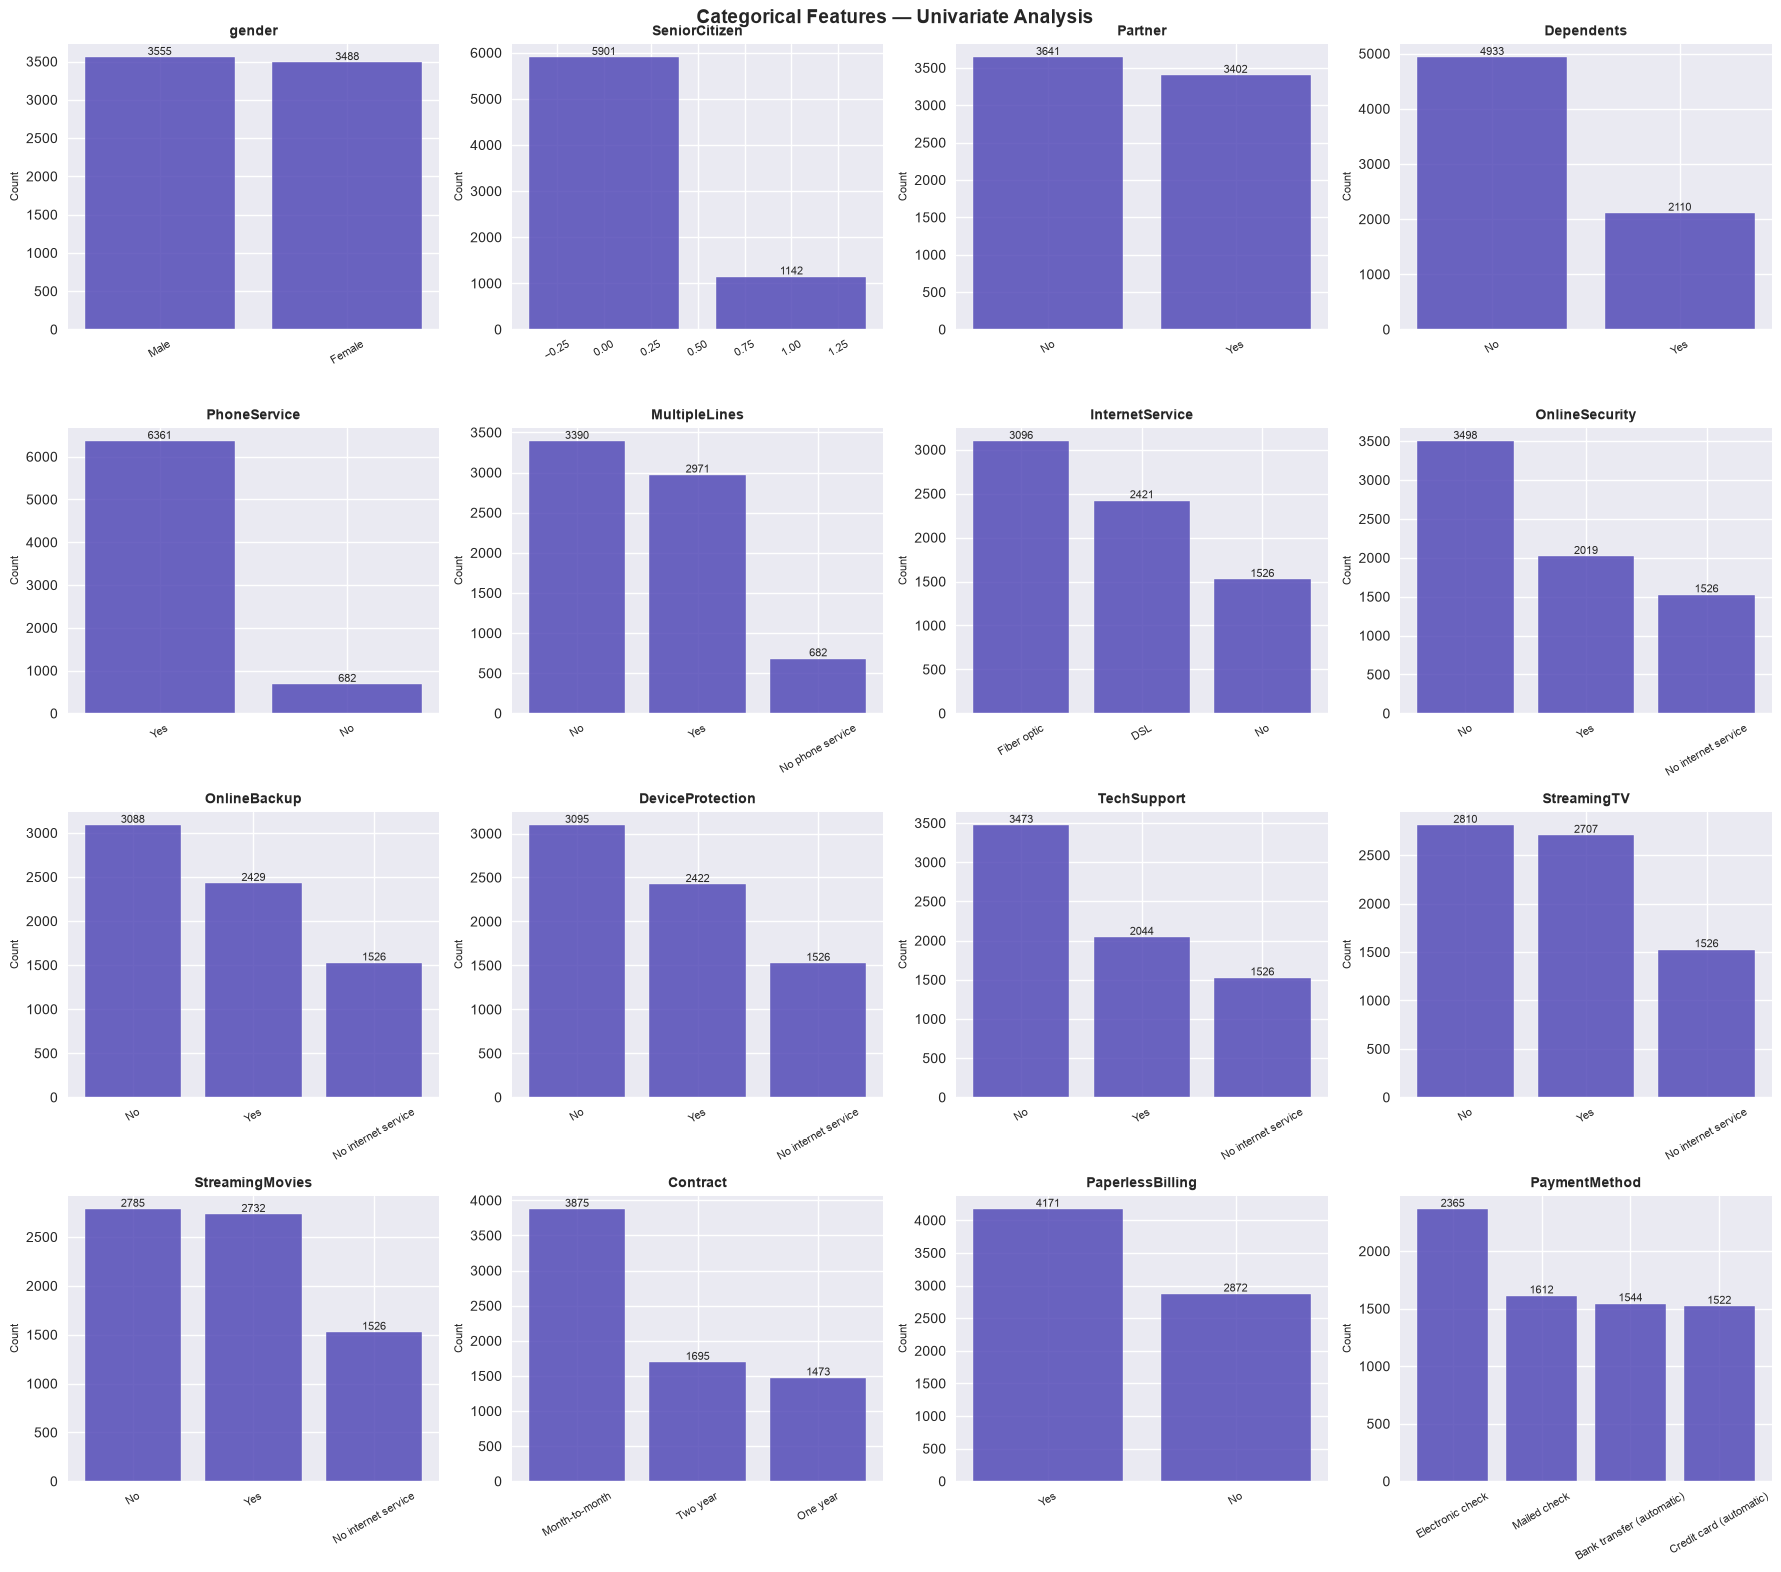

In [ ]:
#  bar charts for all categorical columns
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    bars = axes[idx].bar(counts.index, counts.values,
                          color='#534AB7', alpha=0.85, edgecolor='white')
    axes[idx].bar_label(bars, fmt='%d', fontsize=8)
    axes[idx].set_title(col, fontweight='bold', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=30, labelsize=8)
    axes[idx].set_ylabel('Count', fontsize=8)

# Hide any unused subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Categorical Features — Univariate Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  write your EDA observations
observations = """
## Day 3 EDA Observations

### Class Imbalance
- 73.5% retained, 26.5% churned — 3:1 ratio
- Will use SMOTE in Week 2 to balance before training

### Numerical Features
- tenure: Right skewed — many new customers (high churn risk group)
- MonthlyCharges: Roughly uniform $20-$100, some clustering at low end
- TotalCharges: Highly right skewed — reflects tenure × monthly charges

### Categorical Features
- Contract: Most customers are month-to-month (highest churn risk)
- InternetService: Fibre optic is most common
- PaymentMethod: Electronic check is most common payment method
- TechSupport / OnlineSecurity: Majority have No — potential churn driver

### Next Steps (Day 4)
- Bivariate analysis: each feature vs Churn
- Find which features most strongly predict churn
"""

with open('reports/eda_notes.md', 'a' , encoding = "utf-8" ) as f:
    f.write(observations)

print("Observations saved!")

Observations saved!


tenure:
  Retained mean : 37.57
  Churned mean  : 17.98

MonthlyCharges:
  Retained mean : 61.27
  Churned mean  : 74.44

TotalCharges:
  Retained mean : 2555.34
  Churned mean  : 1531.80



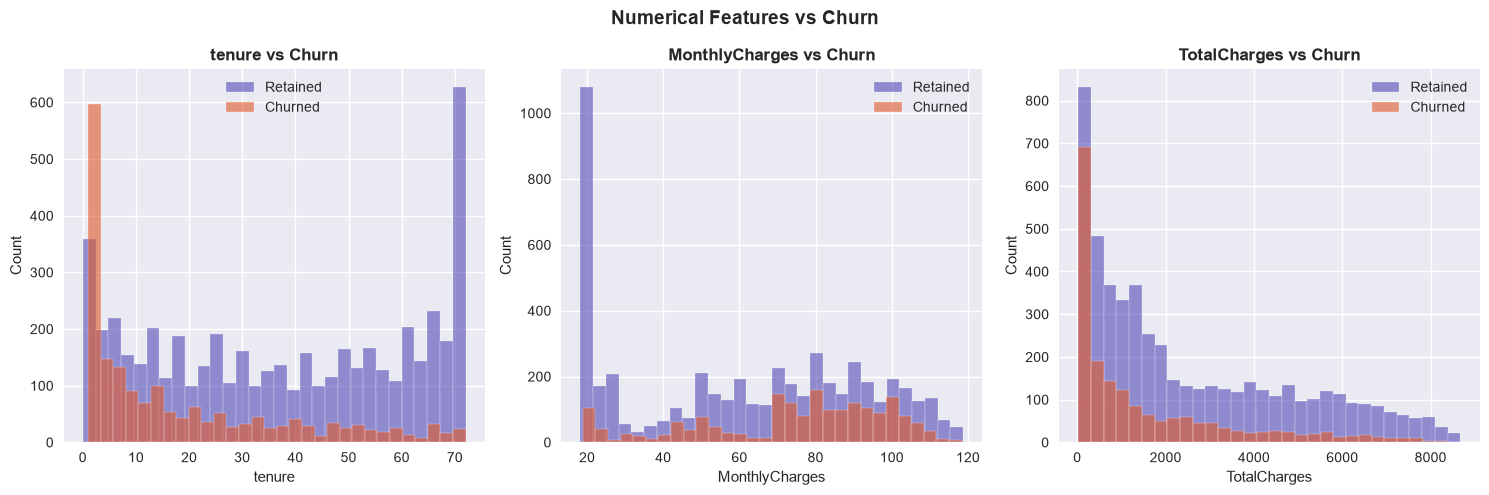

In [22]:
#  numerical features vs churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for idx, col in enumerate(numerical_cols):
    # Separate churned vs retained
    churned    = df[df['Churn'] == 'Yes'][col].dropna()
    retained   = df[df['Churn'] == 'No'][col].dropna()

    axes[idx].hist(retained, bins=30, alpha=0.6,
                   color='#534AB7', label='Retained', edgecolor='white')
    axes[idx].hist(churned, bins=30, alpha=0.6,
                   color='#E05A2B', label='Churned', edgecolor='white')

    axes[idx].set_title(f'{col} vs Churn', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend()

    # Print mean comparison
    print(f"{col}:")
    print(f"  Retained mean : {retained.mean():.2f}")
    print(f"  Churned mean  : {churned.mean():.2f}")
    print()

plt.suptitle('Numerical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/numerical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

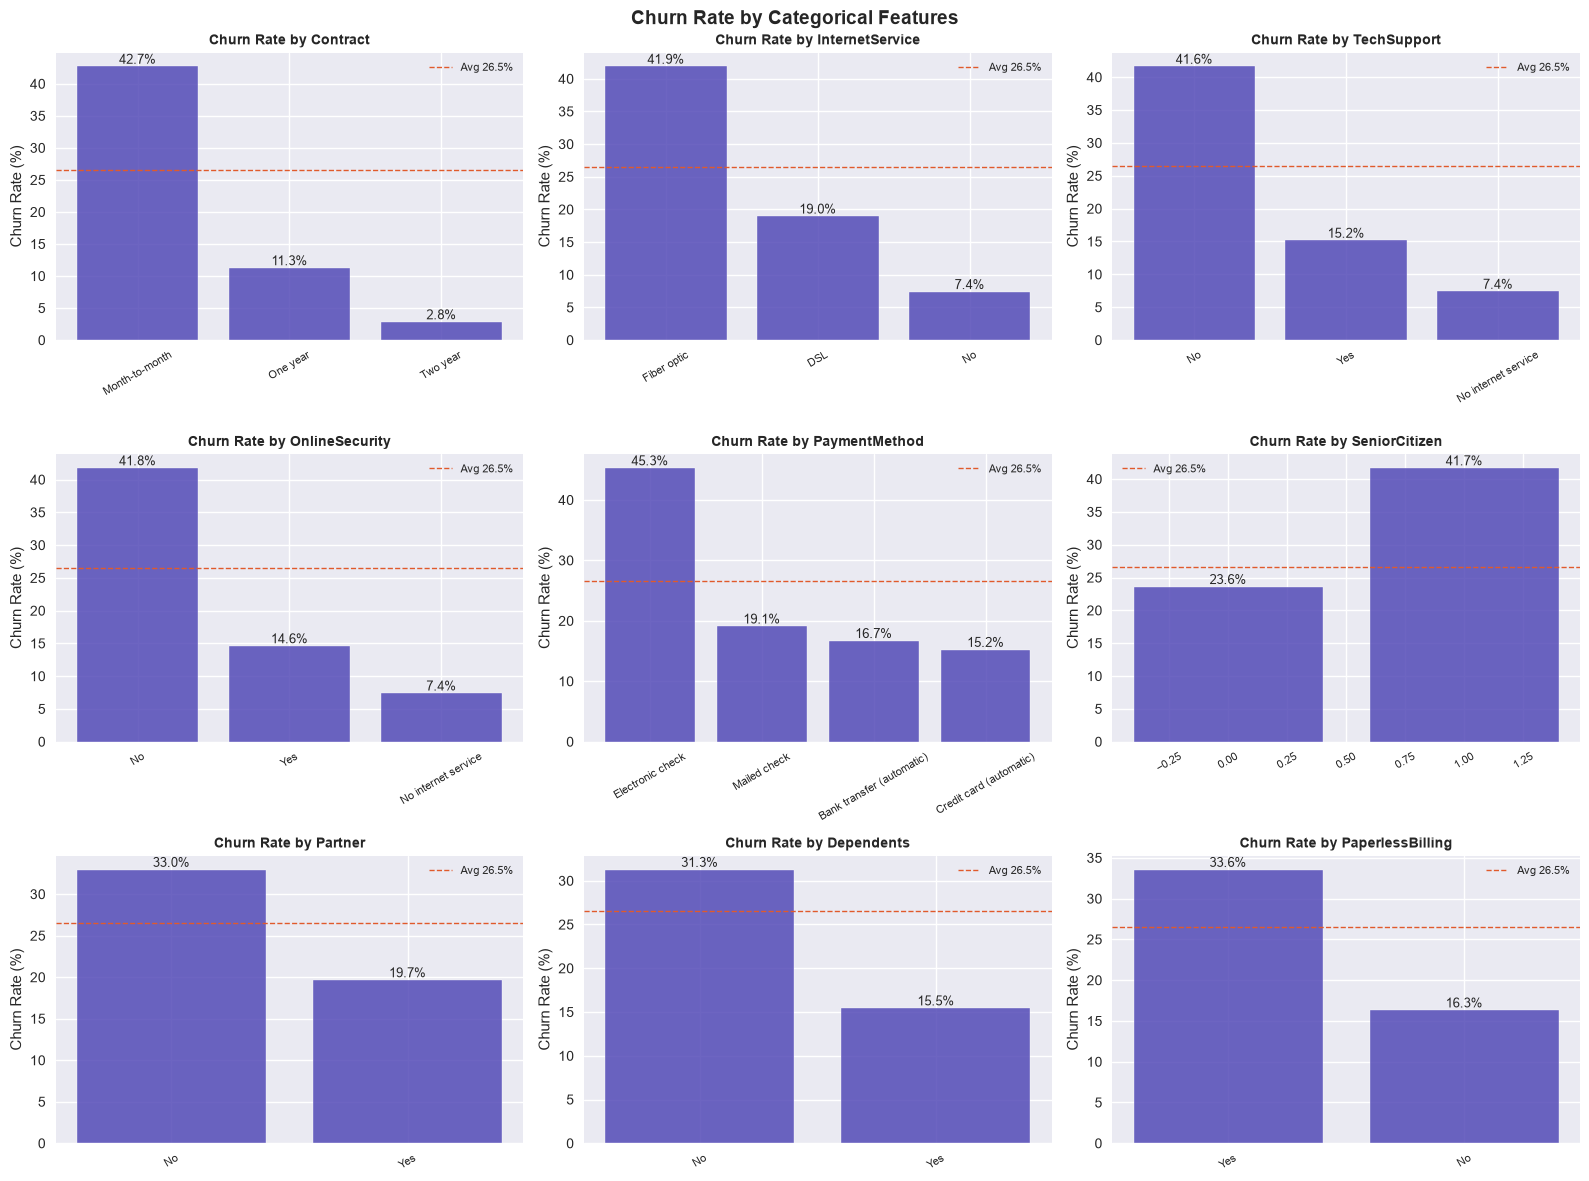

In [25]:
# categorical features vs churn rate
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)
avg_churn_rate = df['Churn_Binary'].mean() * 100
categorical_cols = ['Contract', 'InternetService', 'TechSupport',
                    'OnlineSecurity', 'PaymentMethod', 'SeniorCitizen',
                    'Partner', 'Dependents', 'PaperlessBilling']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    # Calculate churn rate per category
    churn_rate = df.groupby(col)['Churn_Binary'].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False)

    bars = axes[idx].bar(churn_rate.index, churn_rate.values,
                          color='#534AB7', alpha=0.85, edgecolor='white')
    axes[idx].bar_label(bars, fmt='%.1f%%', fontsize=9)
    axes[idx].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].tick_params(axis='x', rotation=30, labelsize=8)
    axes[idx].axhline(y=avg_churn_rate, color='#E05A2B', linestyle='--',
                       linewidth=1, label='Avg 26.5%')
    axes[idx].legend(fontsize=8)

plt.suptitle('Churn Rate by Categorical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/categorical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

Churn Rate by Contract Type:
                Churn Rate %  Customer Count
Contract                                    
Month-to-month         42.70            3875
One year               11.30            1473
Two year                2.80            1695


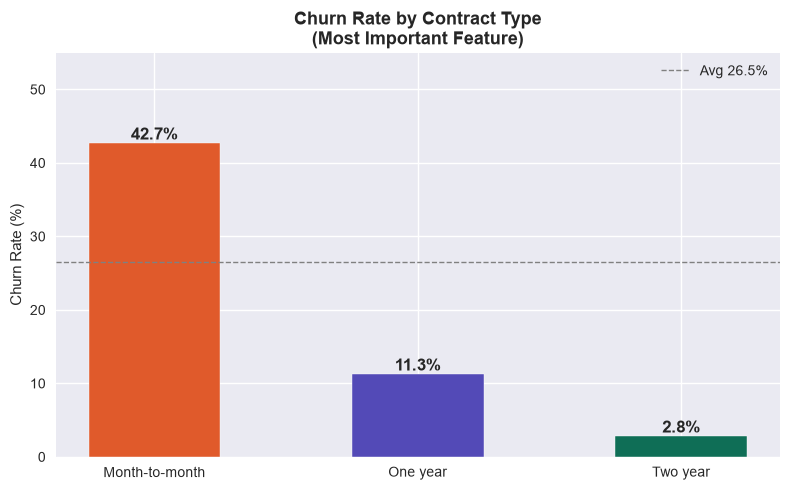

In [26]:
# contract type is the strongest predictor
contract_churn = df.groupby('Contract')['Churn_Binary'].agg(['mean', 'count'])
contract_churn['mean'] = contract_churn['mean'] * 100
contract_churn.columns = ['Churn Rate %', 'Customer Count']

print("Churn Rate by Contract Type:")
print(contract_churn.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E05A2B', '#534AB7', '#0F6E56']
bars = ax.bar(contract_churn.index,
              contract_churn['Churn Rate %'],
              color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.1f%%', fontsize=12, fontweight='bold')
ax.axhline(y= avg_churn_rate, color='gray', linestyle='--', linewidth=1, label='Avg 26.5%')
ax.set_title('Churn Rate by Contract Type\n(Most Important Feature)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.legend()
plt.tight_layout()
plt.savefig('reports/contract_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

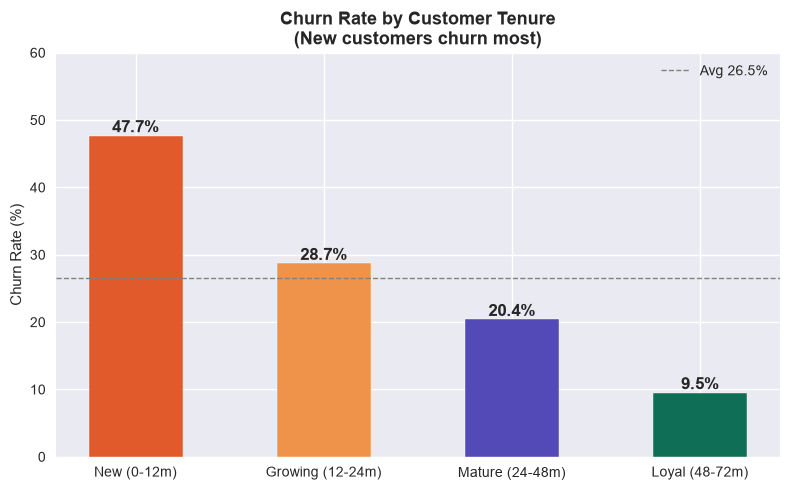


Churn Rate by Tenure Bucket:
tenure_bucket
New (0-12m)        47.70
Growing (12-24m)   28.70
Mature (24-48m)    20.40
Loyal (48-72m)      9.50
Name: Churn_Binary, dtype: float64


In [28]:
# tenure buckets show new customers churn most
df['tenure_bucket'] = pd.cut(df['tenure'],
                              bins=[0, 12, 24, 48, 72],
                              labels=['New (0-12m)', 'Growing (12-24m)',
                                      'Mature (24-48m)', 'Loyal (48-72m)'])

tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn_Binary'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E05A2B', '#F0934A', '#534AB7', '#0F6E56']
bars = ax.bar(tenure_churn.index, tenure_churn.values,
               color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.1f%%', fontsize=12, fontweight='bold')
ax.set_title('Churn Rate by Customer Tenure\n(New customers churn most)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
ax.axhline(y=avg_churn_rate, color='gray', linestyle='--', linewidth=1, label='Avg 26.5%')
ax.legend()
plt.tight_layout()
plt.savefig('reports/tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChurn Rate by Tenure Bucket:")
print(tenure_churn.round(1))

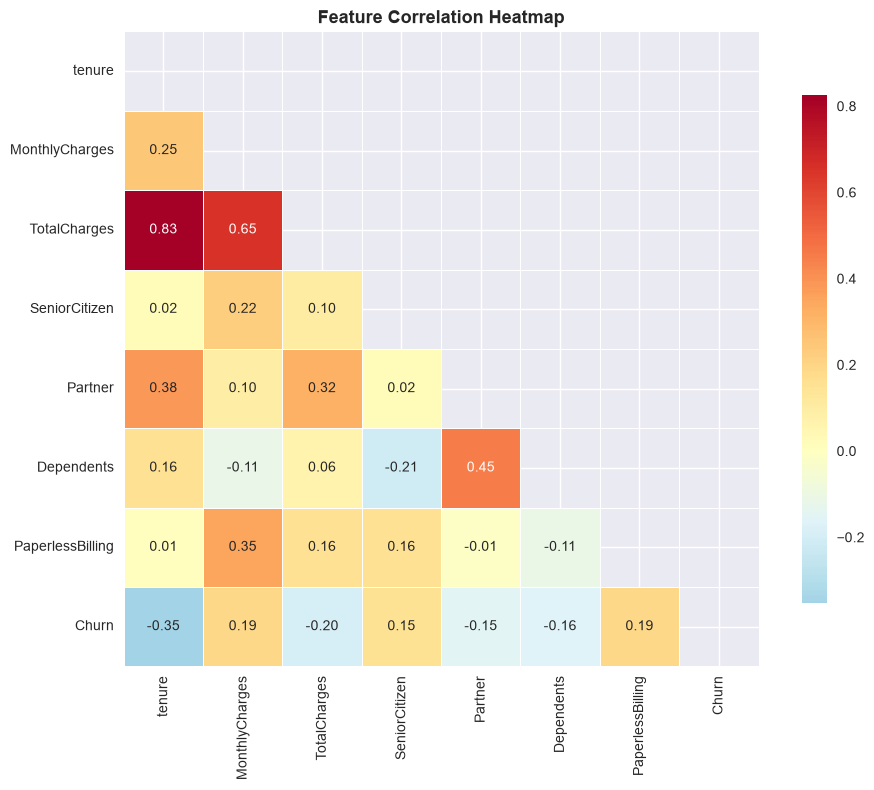


Top correlations with Churn:
tenure             -0.35
TotalCharges       -0.20
MonthlyCharges      0.19
PaperlessBilling    0.19
Dependents         -0.16
SeniorCitizen       0.15
Partner            -0.15
Name: Churn, dtype: float64


In [29]:
# correlation heatmap (numerical features only)

# First encode categoricals to numbers for correlation
df_encoded = df.copy()

# Binary columns — Yes/No → 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

# Select columns for correlation
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
             'SeniorCitizen', 'Partner', 'Dependents',
             'PaperlessBilling', 'Churn']

corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlBu_r',
            center=0,
            square=True,
            ax=ax,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Churn
print("\nTop correlations with Churn:")
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr.round(3))

In [30]:
# Cell  — final business insights
insights = """
## Day 4 — Business Insights from EDA

### Top Churn Risk Factors Found

| Factor | Finding | Churn Rate |
|--------|---------|------------|
| Contract type | Month-to-month customers | 42.7% |
| Tenure | New customers (0-12 months) | ~47% |
| TechSupport | Customers with no support | ~41% |
| OnlineSecurity | No security subscription | ~41% |
| MonthlyCharges | Higher charges = more churn | +0.19 corr |

### Key Business Recommendations
1. Incentivise month-to-month customers to upgrade to annual contracts
2. Prioritise retention efforts in first 12 months of customer lifecycle
3. Offer TechSupport and OnlineSecurity bundles to at-risk segments
4. High monthly charge customers need proactive outreach

### Model Implications
- Contract, tenure, TechSupport, OnlineSecurity → likely top SHAP features
- Class imbalance (26.5% churn) → SMOTE needed before XGBoost training
- TotalCharges and tenure highly correlated → may need to watch multicollinearity
"""

with open('reports/eda_notes.md', 'a' , encoding = "utf-8" ) as f:
    f.write(insights)

print("Business insights saved!")
print("\nDay 4 EDA complete!")

Business insights saved!

Day 4 EDA complete!
